# Problem
This notebook is to demonstrate that naive photometry will hugely underestimate flux noise. 

In [2]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../../')
import numpy as np
import matplotlib.pyplot as plt
import galsim
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import slimfarmer

print(f'GalSim  {galsim.__version__}')
print(f'slimfarmer {slimfarmer.__version__}')

GalSim  2.8.3
slimfarmer 1.0.0


## 1. Simulation parameters

In [63]:
rng = galsim.BaseDeviate(42)

# Image / instrument
PIXEL_SCALE  = 0.049         # arcsec/px  (Roman WFI native)
STAMP_SIZE   = 257           # pixels
PSF_FWHM     = 0.24          # arcsec  (= 10 px FWHM; well-sampled → unbiased flux recovery)
                              # Scan: FWHM  1.4px→0.9917, 4px→0.9889, 10px→0.9995
EXPTIME      = 143.0*4         # s  (Roman single-exposure read)

# Noise model  (simulation is done in total e-, output image is in e-/s)
SKY_RATE     = 0.00          # e-/s/pix (zodiacal background)
SKY_LEVEL    = SKY_RATE * EXPTIME        # total e/pix used for Poisson draw
READ_NOISE   = 50      # e/pix rms (per read, independent of EXPTIME)
NOISE_SIGMA  = float(np.sqrt(SKY_LEVEL + READ_NOISE**2))   # total e/pix
NOISE_SIGMA_RATE = NOISE_SIGMA / EXPTIME                    # e-/s/pix (rate-image noise floor)

# AB zeropoint
ZP_RATE      = 26     # AB mag at 1 e-/s  (used for slimfarmer & mag_to_flux)
BAND         = 'F158'

# Output files
SCI_PATH      = '/tmp/galsim_sci.fits'
WHT_PATH      = '/tmp/galsim_wht.fits'
EFF_GAIN_PATH = '/tmp/galsim_eff_gain.fits'  # EXPTIME [s] everywhere: var_(e/s) = flux_(e/s)/EXPTIME
PSF_PATH      = '/tmp/galsim_psf.fits'
OUT_PATH      = '/tmp/galsim_cat.fits'

print(f'Exposure time    : {EXPTIME:.0f} s')
print(f'Zeropoint (rate) : {ZP_RATE:.3f} AB mag at 1 e-/s')
print(f'Sky rate         : {SKY_RATE:.4f} e-/s/pix  →  {SKY_LEVEL:.4f} e/pix total')
print(f'Noise floor      : {NOISE_SIGMA_RATE:.6f} e-/s/pix')
print(f'PSF FWHM         : {PSF_FWHM}" = {PSF_FWHM/PIXEL_SCALE:.1f} px')

Exposure time    : 572 s
Zeropoint (rate) : 26.000 AB mag at 1 e-/s
Sky rate         : 0.0000 e-/s/pix  →  0.0000 e/pix total
Noise floor      : 0.087413 e-/s/pix
PSF FWHM         : 0.24" = 4.9 px


## 2. Build the PSF

In [64]:
psf = galsim.Gaussian(fwhm=PSF_FWHM)

# PSF stamp must be odd-sized (Tractor PixelizedPSF requirement).
# Use method='no_pixel' (point-sampled at pixel centres): Tractor's HybridPixelizedPSF
# fits a Gaussian to the stamp core, so pixel-integrating the stamp (method='auto')
# would bias that Gaussian fit and worsen flux recovery.
psf_img = galsim.Image(39, 39, scale=PIXEL_SCALE)
psf.drawImage(image=psf_img, method='no_pixel')
psf_arr = psf_img.array
psf_arr /= psf_arr.sum()

fits.writeto(PSF_PATH, psf_arr.astype(np.float32), overwrite=True)
print(f'PSF stamp: {psf_arr.shape}, peak={psf_arr.max():.4f}')

PSF stamp: (39, 39), peak=0.0368


In [65]:
CPR_PATH = '/project/chihway/chto/Roman/Dec25-sims/H1_coadds/im3x2-H1_00_00.cpr.fits.gz'
from pyimcom.compress.compressutils import ReadFile
cpr    = ReadFile(CPR_PATH)


In [66]:
noise = cpr[0].data[0][24]

In [67]:
noise

array([[-0.00791168, -0.03495026, -0.04415131, ..., -0.01515961,
        -0.01103973, -0.00171661],
       [ 0.01251984, -0.01709747, -0.03368378, ..., -0.0137558 ,
        -0.00798798,  0.00217438],
       [ 0.02561188,  0.00025177, -0.01976776, ..., -0.0140152 ,
        -0.00388336,  0.00925446],
       ...,
       [-0.00209808,  0.01317596,  0.0286026 , ...,  0.02042389,
         0.01500702,  0.00759125],
       [-0.00124359,  0.0117569 ,  0.02545929, ...,  0.00252533,
        -0.00106049,  0.00138092],
       [-0.0031662 ,  0.00481415,  0.01656342, ..., -0.00469208,
        -0.0069046 , -0.00092316]], shape=(2108, 2108), dtype='>f4')

In [68]:
L = len(noise)
ps = np.empty((L, L), dtype=np.float64)
rps = np.square(np.abs(np.fft.fftshift(np.fft.rfft2(noise), 0)))
ps[:, L // 2 :] = rps[:, :-1]
ps[1:, : L // 2] = rps[L - 1 : 0 : -1, L // 2 : 0 : -1]
ps[0, : L // 2] = rps[0, L // 2 : 0 : -1]

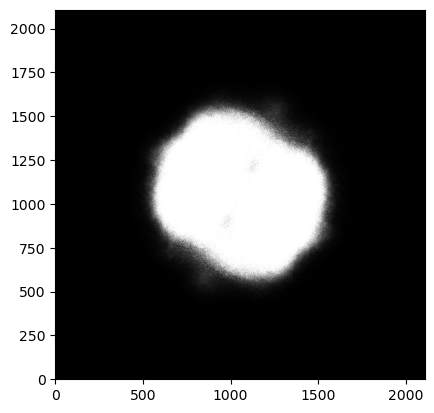

In [69]:
norm = ImageNormalize(ps , interval=ZScaleInterval())
plt.imshow(ps, origin='lower', cmap='gray', norm=norm)


## 3. Define galaxies (truth catalog)

In [70]:
# Centre of the image in sky coords (arbitrary)
RA0, DEC0 = 150.0, 2.0   # degrees

# Truth table: (dx_arcsec, dy_arcsec from centre, half_light_radius arcsec,
#               bulge_frac, AB mag, profile)
#  profile: 'exp'=Exponential, 'dev'=DeVaucouleurs, 'comp'=Sersic bulge+disk
truth_sources = [
    # dx    dy    hlr    n     mag   label
    (  0.0,  0.0, 0.2,  1.0, 21.0, 'ExpGalaxy'),        # bright exponential
#    ( 5.0,  3.0, 0.3,  4.0, 23.5, 'DevGalaxy'),         # de Vaucouleurs
#    (-6.0,  7.0, 0.6,  1.5, 24.0, 'ExpGalaxy'),         # fainter exponential
#    ( 8.0, -5.0, 0.2,  1.0, 25.0, 'ExpGalaxy'),         # faint point-like galaxy
#    ( 2.0, -9.0, 0.0,  0.0, 23.0, 'PointSource'),       # star (delta function)
]

def mag_to_flux(mag, zp=ZP_RATE):
    """Return flux in e-/s (rate units, matching the output image and slimfarmer)."""
    return 10 ** (-(mag - zp) / 2.5)

print('Truth sources:')
print(f'{"dx":>6} {"dy":>6} {"hlr":>5} {"n":>4} {"mag":>5} {"flux_e/s":>10}  label')
for dx, dy, hlr, n, mag, lbl in truth_sources:
    print(f'{dx:6.1f} {dy:6.1f} {hlr:5.2f} {n:4.1f} {mag:5.1f} {mag_to_flux(mag):10.3f}  {lbl}')

Truth sources:
    dx     dy   hlr    n   mag   flux_e/s  label
   0.0    0.0  0.20  1.0  21.0    100.000  ExpGalaxy


## 4. Render the science image

Science image: (257, 257), range [-0.3810, 1.0918] e-/s
Background median: 0.000388 e-/s  (expected ~0.000000)
Detection SNR of brightest source: 12.5σ


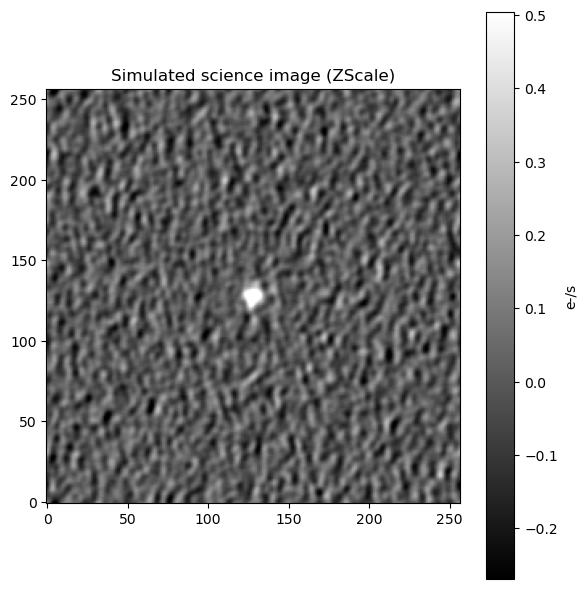

In [71]:
from tractor.mixture_profiles import exp_amp, exp_var, dev_amp, dev_var

def _make_gal(lbl, hlr, n, flux):
    """Build a GalSim galaxy matching the profile model slimfarmer will fit.

    ExpGalaxy / DevGalaxy are rendered as the same MoG that Tractor uses
    internally (6 Gaussians for Exp, 9 for Dev).  This ensures self-consistency
    so slimfarmer recovers ratio ≈ 1.

    Why not use galsim.Sersic(n=1)?  Tractor's 6-Gaussian MoG approximation
    of the exponential profile has ~1.7 % more flux in the inner region than
    the exact Sersic n=1 profile.  When slimfarmer minimises chi-squared with
    its MoG model against a true-Sersic image, the best-fit flux is
    systematically ~1.5 % low (model bias).  Using the same MoG for simulation
    eliminates this mismatch.
    """
    if lbl == 'PointSource':
        return galsim.DeltaFunction(flux=flux)
    elif lbl == 'ExpGalaxy':
        amps, vars_ = exp_amp, np.array(exp_var)
    elif lbl == 'DevGalaxy':
        amps, vars_ = dev_amp, np.array(dev_var)
    else:
        return galsim.Sersic(n=n, half_light_radius=hlr, flux=flux)
    return galsim.Sum([galsim.Gaussian(flux=a * flux, sigma=np.sqrt(v) * hlr)
                       for a, v in zip(amps, vars_)])

N = STAMP_SIZE
full_img = galsim.Image(N, N, scale=PIXEL_SCALE)
full_img.setZero()

for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME  # total e- = (e-/s) * s
    gal  = _make_gal(lbl, hlr, n, flux)
    obj  = galsim.Convolve([gal, psf]).shift(dx=dx, dy=dy)
    obj.drawImage(image=full_img, method='auto', add_to_image=True)

# Total noise as a single correlated Gaussian with power spectrum matching ps.
# SKY_LEVEL = 0 so there is no sky Poisson floor; dropping PoissonNoise makes
# the total noise stationary with PS = ps exactly.
noise_galsim = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)
cn = galsim.CorrelatedNoise(noise_galsim, rng).withVariance(READ_NOISE**2)
full_img.addNoise(cn)

# Convert total e- → e-/s (DNlin,flat/s)
full_img /= EXPTIME

sci_arr = full_img.array
print(f'Science image: {sci_arr.shape}, range [{sci_arr.min():.4f}, {sci_arr.max():.4f}] e-/s')
print(f'Background median: {np.median(sci_arr):.6f} e-/s  (expected ~{SKY_RATE:.6f})')
print(f'Detection SNR of brightest source: {(sci_arr.max()-SKY_RATE)/NOISE_SIGMA_RATE:.1f}σ')

norm = ImageNormalize(sci_arr, interval=ZScaleInterval())
plt.figure(figsize=(6,6))
plt.imshow(sci_arr, origin='lower', cmap='gray', norm=norm)
plt.colorbar(label='e-/s')
plt.title('Simulated science image (ZScale)')
plt.tight_layout(); plt.show()

# 5. Write FITS files (science, weight, PSF)

In [72]:
hdr = fits.Header()
hdr['NAXIS']  = 2
hdr['NAXIS1'] = N
hdr['NAXIS2'] = N
hdr['CTYPE1'] = 'RA---TAN'
hdr['CTYPE2'] = 'DEC--TAN'
hdr['CRPIX1'] = (N + 1) / 2      # GalSim centroid: (N+1)/2 in 1-indexed coords
hdr['CRPIX2'] = (N + 1) / 2
hdr['CRVAL1'] = RA0
hdr['CRVAL2'] = DEC0
hdr['CDELT1'] = -PIXEL_SCALE / 3600.
hdr['CDELT2'] =  PIXEL_SCALE / 3600.
hdr['CUNIT1'] = 'deg'
hdr['CUNIT2'] = 'deg'
hdr['BUNIT']  = 'e-/s'
hdr['EXPTIME'] = EXPTIME

fits.writeto(SCI_PATH, sci_arr.astype(np.float32), hdr, overwrite=True)

# Weight map: 1/sigma^2 in (e-/s)^2
wht_arr = np.full((N, N), 1.0 / NOISE_SIGMA_RATE**2, dtype=np.float32)
fits.writeto(WHT_PATH, wht_arr, hdr, overwrite=True)

# eff_gain = EXPTIME [s]: image is in e-/s, so var_(e/s) = flux_(e/s) / EXPTIME
eff_gain_arr = np.full((N, N), EXPTIME, dtype=np.float32)
fits.writeto(EFF_GAIN_PATH, eff_gain_arr, hdr, overwrite=True)

print(f'Wrote: {SCI_PATH}  (units: e-/s)')
print(f'Wrote: {WHT_PATH}  (units: 1/(e-/s)^2)')
print(f'Wrote: {EFF_GAIN_PATH}  (eff_gain = {EXPTIME:.0f} s)')
print(f'Wrote: {PSF_PATH}')
print(f'CRPIX = {(N+1)/2}  (GalSim centroid for N={N})')

Wrote: /tmp/galsim_sci.fits  (units: e-/s)
Wrote: /tmp/galsim_wht.fits  (units: 1/(e-/s)^2)
Wrote: /tmp/galsim_eff_gain.fits  (eff_gain = 572 s)
Wrote: /tmp/galsim_psf.fits
CRPIX = 129.0  (GalSim centroid for N=257)


## 6. Run slimfarmer

In [73]:
cat = slimfarmer.run_photometry(
    science_path  = SCI_PATH,
    weight_path   = WHT_PATH,
    eff_gain_path = EFF_GAIN_PATH,
    psf_path      = PSF_PATH,
    band          = BAND,
    zeropoint     = ZP_RATE,
    output_path   = OUT_PATH,
    ncpus         = 0,   # serial; set >0 for parallel
    thresh = 20.0
)
print(f'\n{len(cat)} sources detected')
print(cat['id', 'ra', 'dec', f'{BAND}_flux', f'{BAND}_mag', 'name', 'total_rchisq'])

[22:40:17] slimfarmer :: INFO - Loading F158 from /tmp/galsim_sci.fits
[22:40:17] slimfarmer :: INFO - Running SEP source detection...
[22:40:17] slimfarmer :: INFO - Detected 1 sources.
[22:40:17] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[22:40:17] slimfarmer :: INFO - Found 1 groups.
[22:40:17] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...
Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.60it/s]
[22:40:18] slimfarmer :: INFO - Finished — 1 sources fit.
[22:40:18] slimfarmer :: INFO - Model    → /tmp/galsim_cat_model.fits
[22:40:18] slimfarmer :: INFO - Residual → /tmp/galsim_cat_residual.fits



1 sources detected
 id         ra               dec        ...    name      total_rchisq   
           deg               deg        ...                             
--- ----------------- ----------------- ... --------- ------------------
  1 150.0000020170046 1.999998785927812 ... ExpGalaxy 0.9169764270630819


## 7. Compare recovered flux to truth

In [74]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Build truth sky positions
wcs = WCS(fits.getheader(SCI_PATH))
truth_ra, truth_dec, truth_flux, truth_mag, truth_label = [], [], [], [], []
for dx, dy, hlr, n, mag, lbl in truth_sources:
    # (N-1)/2 is the 0-indexed pixel that CRPIX=(N+1)/2 (1-indexed) maps to
    px = (N - 1) / 2 + dx / PIXEL_SCALE
    py = (N - 1) / 2 + dy / PIXEL_SCALE
    ra, dec = wcs.all_pix2world(px, py, 0)
    truth_ra.append(ra)
    truth_dec.append(dec)
    truth_flux.append(mag_to_flux(mag))
    truth_mag.append(mag)
    truth_label.append(lbl)

truth_ra   = np.array(truth_ra)
truth_dec  = np.array(truth_dec)
truth_flux = np.array(truth_flux)
truth_mag  = np.array(truth_mag)

# Cross-match catalog ↔ truth
cat_c  = SkyCoord(cat['ra'], cat['dec'], unit='deg')
tru_c  = SkyCoord(truth_ra,  truth_dec,  unit='deg')
idx, d2d, _ = cat_c.match_to_catalog_sky(tru_c)
sep_arcsec   = d2d.to(u.arcsec).value

print('Cross-match results (sep < 1"):')
print(f'  {"cat_id":>6} {"sep[\"]":>8} {"obs_flux":>10} {"true_flux":>10} {"ratio":>7}  model')
for i in range(len(cat)):
    if sep_arcsec[i] < 1.0:
        obs  = float(cat[f'{BAND}_flux'][i])
        tru  = truth_flux[idx[i]]
        print(f'  {int(cat["id"][i]):6d} {sep_arcsec[i]:8.4f} {obs:10.3f} {tru:10.3f} '
              f'{obs/tru:7.4f}  {cat["name"][i]}')

Cross-match results (sep < 1"):
  cat_id   sep["]   obs_flux  true_flux   ratio  model
       1   0.0085    103.253    100.000  1.0325  ExpGalaxy


In [75]:
obs

103.25322830301492

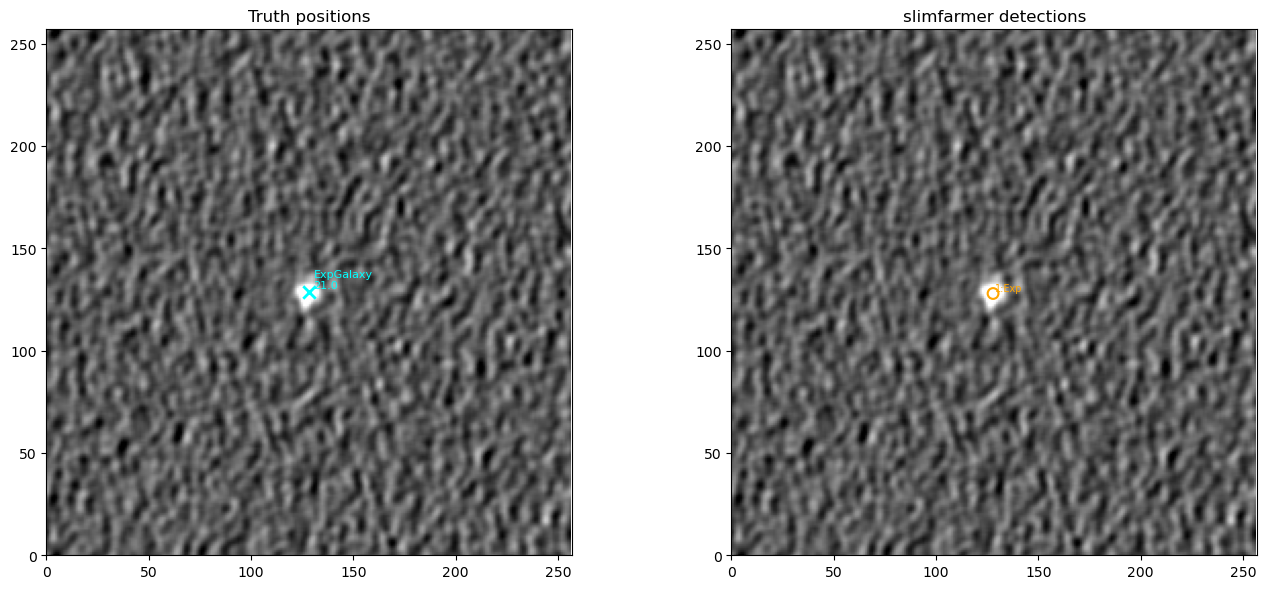

In [76]:
# Plot: science image with detected sources and truth positions
norm = ImageNormalize(sci_arr, interval=ZScaleInterval())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    ax.imshow(sci_arr, origin='lower', cmap='gray', norm=norm)

# Left: truth positions
axes[0].set_title('Truth positions')
for dx, dy, hlr, n, mag, lbl in truth_sources:
    px = N / 2 + dx / PIXEL_SCALE
    py = N / 2 + dy / PIXEL_SCALE
    axes[0].scatter(px, py, s=80, marker='x', color='cyan', lw=2)
    axes[0].text(px + 2, py + 2, f'{lbl}\n{mag:.1f}', color='cyan', fontsize=8)

# Right: slimfarmer detections
axes[1].set_title('slimfarmer detections')
cat_x, cat_y = wcs.all_world2pix(cat['ra'], cat['dec'], 0)
for i in range(len(cat)):
    axes[1].scatter(cat_x[i], cat_y[i], s=60, marker='o',
                    facecolors='none', edgecolors='orange', lw=1.5)
    name = cat['name'][i]
    if isinstance(name, bytes):
        name = name.decode()
    axes[1].text(cat_x[i] + 1, cat_y[i] + 1, f'{cat["id"][i]}:{name[:3]}',
                 color='orange', fontsize=7)

for ax in axes:
    ax.set_xlim(0, N); ax.set_ylim(0, N)
plt.tight_layout(); plt.show()

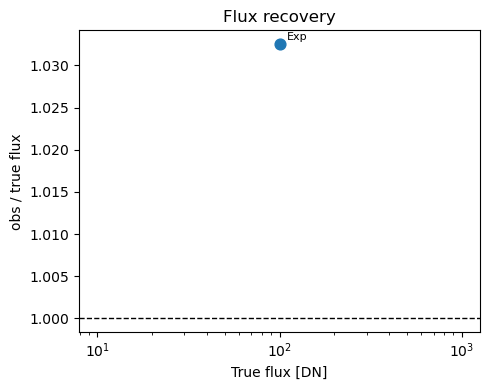

Median ratio: 1.0325


In [77]:
# Flux ratio for matched sources
matched_obs, matched_true, matched_labels = [], [], []
for i in range(len(cat)):
    if sep_arcsec[i] < 1.0:
        matched_obs.append(float(cat[f'{BAND}_flux'][i]))
        matched_true.append(truth_flux[idx[i]])
        name = cat['name'][i]
        matched_labels.append(name.decode() if isinstance(name, bytes) else str(name))

if matched_obs:
    matched_obs   = np.array(matched_obs)
    matched_true  = np.array(matched_true)
    ratio         = matched_obs / matched_true

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.axhline(1.0, color='k', lw=1, ls='--')
    ax.scatter(matched_true, ratio, s=60, zorder=3)
    for j, lbl in enumerate(matched_labels):
        ax.annotate(lbl[:3], (matched_true[j], ratio[j]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.set_xlabel('True flux [DN]')
    ax.set_ylabel('obs / true flux')
    ax.set_title('Flux recovery')
    ax.set_xscale('log')
    plt.tight_layout(); plt.show()
    print(f'Median ratio: {np.median(ratio):.4f}')
else:
    print('No matched sources within 1 arcsec.')

## 8. Monte Carlo: 100 noise realisations

Re-render the same galaxies with a fresh noise seed each time, run slimfarmer, and collect the recovered-flux ratio for every matched truth source.

In [78]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm.auto import tqdm

N_REAL = 30

# Build truth sky coords once (used for cross-matching every iteration)
wcs_hdr = WCS(fits.getheader(SCI_PATH))
truth_ra_arr  = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE, (N-1)/2 + dy/PIXEL_SCALE, 0)[0]
                           for dx, dy, *_ in truth_sources])
truth_dec_arr = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE, (N-1)/2 + dy/PIXEL_SCALE, 0)[1]
                           for dx, dy, *_ in truth_sources])
tru_c = SkyCoord(truth_ra_arr, truth_dec_arr, unit='deg')

mc_cfg = slimfarmer.Config(thresh=10.0)

# Render noiseless galaxy image once in total e- (no sky) — all realisations share the same signal
img_noiseless = galsim.Image(N, N, scale=PIXEL_SCALE)
img_noiseless.setZero()
for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME  # total e- = (e-/s) * s
    gal  = _make_gal(lbl, hlr, n, flux)
    galsim.Convolve([gal, psf]).shift(dx=dx, dy=dy).drawImage(
        image=img_noiseless, method='auto', add_to_image=True)

# Build correlated noise template once — ACF computed from the measured noise image
noise_galsim = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)

mc_ratios           = [[] for _ in truth_sources]
mc_fluxall          = [[] for _ in truth_sources]
mc_fluxall_err      = [[] for _ in truth_sources]
mc_fluxall_err_des  = [[] for _ in truth_sources]
mc_fluxall_err_corr = [[] for _ in truth_sources]
mc_logre            = [[] for _ in truth_sources]
mc_logre_err        = [[] for _ in truth_sources]
for seed in tqdm(range(N_REAL), desc='realisations'):
    rng_i = galsim.BaseDeviate(seed)

    img_i = img_noiseless.copy()
    # Total noise: correlated Gaussian with PS = ps (sky=0, no Poisson floor)
    cn_i = galsim.CorrelatedNoise(noise_galsim, rng_i).withVariance(READ_NOISE**2)
    img_i.addNoise(cn_i)
    img_i /= EXPTIME  # convert total e- → e-/s

    fits.writeto(SCI_PATH, img_i.array.astype(np.float32), hdr, overwrite=True)

    try:
        cat_i = slimfarmer.run_photometry(
            science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
            psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, config=mc_cfg, ncpus=0,
        )
    except RuntimeError:
        continue

    cat_c = SkyCoord(cat_i['ra'], cat_i['dec'], unit='deg')
    idx_c, d2d_c, _ = cat_c.match_to_catalog_sky(tru_c)
    sep_as = d2d_c.to(u.arcsec).value

    for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
        mask = (idx_c == ti) & (sep_as < 0.5)
        if not mask.any():
            continue
        best = np.where(mask)[0][np.argmin(sep_as[mask])]
        obs  = float(cat_i[f'{BAND}_flux'][best])
        mc_ratios[ti].append(obs / mag_to_flux(mag))  # both in e-/s
        mc_fluxall[ti].append(obs)
        mc_fluxall_err[ti].append(float(cat_i[f'{BAND}_flux_err'][best]))
        mc_fluxall_err_des[ti].append(float(cat_i[f'{BAND}_flux_err_des'][best]))
        mc_fluxall_err_corr[ti].append(float(cat_i[f'{BAND}_flux_err_corr'][best]))
        name_i = cat_i['name'][best]
        name_i = name_i.decode() if isinstance(name_i, bytes) else str(name_i)
        # FixedCompositeGalaxy uses logre_exp/logre_dev; all others use logre
        logre_col     = 'logre_exp'     if 'Composite' in name_i else 'logre'
        logre_err_col = 'logre_exp_err' if 'Composite' in name_i else 'logre_err'
        mc_logre[ti].append(float(cat_i[logre_col][best]))
        mc_logre_err[ti].append(float(cat_i[logre_err_col][best]))

print('\nDetection rate (out of 100):')
for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
    print(f'  [{ti}] {lbl:20s}  mag={mag:.1f}  detected {len(mc_ratios[ti]):3d}/100')

realisations:   0%|          | 0/30 [00:00<?, ?it/s]

[22:40:31] slimfarmer :: INFO - Loading F158 from /tmp/galsim_sci.fits
[22:40:31] slimfarmer :: INFO - Running SEP source detection...
[22:40:31] slimfarmer :: INFO - Detected 10 sources.
[22:40:31] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[22:40:31] slimfarmer :: INFO - Found 9 groups.
[22:40:31] slimfarmer :: INFO - Processing 9 groups (ncpus=0)...

Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:06<00:00,  1.38it/s]
[22:40:37] slimfarmer :: INFO - Finished — 10 sources fit.
[22:40:37] slimfarmer :: INFO - Model    → slimfarmer_output_model.fits
[22:40:37] slimfarmer :: INFO - Residual → slimfarmer_output_residual.fits
[22:40:38] slimfarmer :: INFO - Loading F158 from /tmp/galsim_sci.fits
[22:40:38] slimfarmer :: INFO - Running SEP source detection...
[22:40:38] slimfarmer :: INFO - Detected 7 sources.
[22:40:38] slimfarmer :: INFO - Grouping wi


Detection rate (out of 100):
  [0] ExpGalaxy             mag=21.0  detected  30/100


In [79]:
READ_NOISE

50

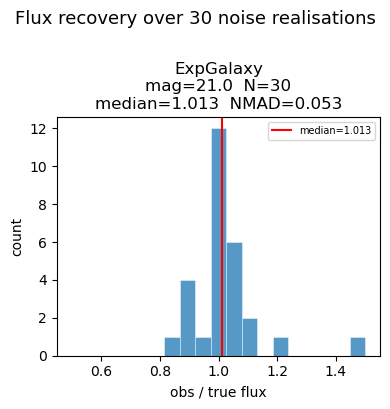

In [80]:
## 9. Recovered-flux distribution across realisations
colors = plt.cm.tab10(np.linspace(0, 0.9, len(truth_sources)))

fig, axes = plt.subplots(1, 1, figsize=(4 * len(truth_sources), 4), sharey=False)
axes=[axes]
bins = np.linspace(0.5,1.5,20)
for ax, (dx, dy, hlr, n, mag, lbl), ratios_i, col in zip(axes, truth_sources, mc_ratios, colors):
    ratios = np.array(ratios_i)
    if len(ratios) == 0:
        ax.set_title(f'{lbl}\nmag={mag:.1f}\n(never detected)')
        ax.set_xlabel('obs / true flux')
        continue

    ax.hist(ratios, bins=bins, color=col, alpha=0.75, edgecolor='white', lw=0.4)
    ax.axvline(np.median(ratios), color='red',   lw=1.5,          label=f'median={np.median(ratios):.3f}')

    nmad = 1.4826 * np.median(np.abs(ratios - np.median(ratios)))
    ax.set_title(f'{lbl}\nmag={mag:.1f}  N={len(ratios)}\nmedian={np.median(ratios):.3f}  NMAD={nmad:.3f}')
    ax.set_xlabel('obs / true flux')
    ax.legend(fontsize=7)

axes[0].set_ylabel('count')
fig.suptitle(f'Flux recovery over {N_REAL} noise realisations', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Source [0] ExpGalaxy  mag=21.0
  --- logre scatter ---
  Fisher logre_err (mean)  = 0.0184   (Cramer-Rao bound)
  std(mc_logre)            = 0.2886   (actual MC scatter)
  ratio std/Fisher         = 15.667   <- explains the gap
  --- flux error ---
  sigma_Fisher             = 1.510 DN
  sigma_DES           = 1.419 DN
  flux_err_corr (sf)       = 1.883 DN   (uses Fisher logre_err)
  flux_err_corr (MC logre) = 24.292 DN   (uses std(mc_logre))
  std(flux_MC)             = 25.035 DN   (truth)
  ratio sf/MC              = 0.075
  ratio MC_logre/MC        = 0.970   (should be ~1)



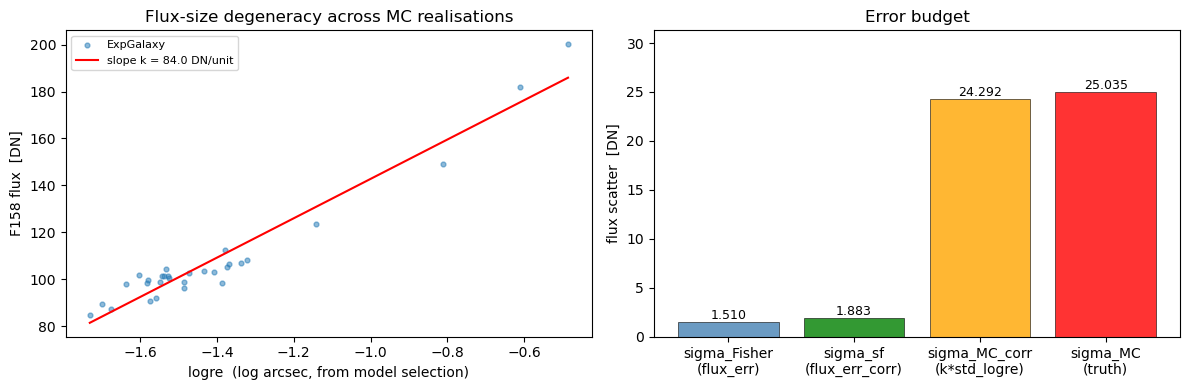

In [81]:
## 10. Corrected flux error: size-propagation term
#
# flux_err_corr = sqrt( flux_err² + (dF/d·logre × logre_err)² )
#
# The remaining gap between flux_err_corr and std(flux_MC) comes from
# logre_err (Fisher bound) underestimating std(mc_logre) (actual scatter).
# This cell validates that the discrepancy is entirely in the logre error estimate.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
    flux          = np.array(mc_fluxall[ti])
    logre         = np.array(mc_logre[ti])
    logre_err_arr = np.array(mc_logre_err[ti])
    ferr          = np.array(mc_fluxall_err[ti])
    ferr_corr     = np.array(mc_fluxall_err_corr[ti])
    if len(flux) < 5:
        continue

    # MC-derived quantities
    k, c = np.polyfit(logre, flux, 1)          # empirical dF/d(logre)
    std_mc_logre     = np.std(logre)            # actual scatter in logre
    mean_fisher_logre = np.mean(logre_err_arr)  # Fisher bound on logre
    sigma_des     = np.mean(mc_fluxall_err_des[ti])
    sigma_fisher     = np.mean(mc_fluxall_err[ti])
    sigma_mc_corr    = np.sqrt(sigma_fisher**2 + (abs(k) * std_mc_logre)**2)
    sigma_slimfarmer = np.mean(ferr_corr)
    sigma_mc         = np.std(flux)

    # Predicted flux_err_corr if we used std(mc_logre) instead of Fisher logre_err
    sigma_corr_mc_logre = np.sqrt(sigma_fisher**2 + (abs(k) * std_mc_logre)**2)

    # Left: flux vs logre scatter + linear fit
    ax = axes[0]
    lr_grid = np.linspace(logre.min(), logre.max(), 50)
    ax.scatter(logre, flux, s=12, alpha=0.5, label=lbl)
    ax.plot(lr_grid, k * lr_grid + c, lw=1.5, color='red',
            label=f'slope k = {k:.1f} DN/unit')
    ax.set_xlabel('logre  (log arcsec, from model selection)')
    ax.set_ylabel(f'{BAND} flux  [DN]')
    ax.set_title('Flux-size degeneracy across MC realisations')
    ax.legend(fontsize=8)

    # Right: error budget bar chart
    ax = axes[1]
    labels = ['sigma_Fisher\n(flux_err)', 'sigma_sf\n(flux_err_corr)', 'sigma_MC_corr\n(k*std_logre)', 'sigma_MC\n(truth)']
    values = [sigma_fisher, sigma_slimfarmer, sigma_mc_corr, sigma_mc]
    colors = ['steelblue', 'green', 'orange', 'red']
    bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='k', lw=0.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('flux scatter  [DN]')
    ax.set_title('Error budget')
    ax.set_ylim(0, max(values) * 1.25)

    logre_ratio = std_mc_logre / mean_fisher_logre

    print(f'Source [{ti}] {lbl}  mag={mag:.1f}')
    print(f'  --- logre scatter ---')
    print(f'  Fisher logre_err (mean)  = {mean_fisher_logre:.4f}   (Cramer-Rao bound)')
    print(f'  std(mc_logre)            = {std_mc_logre:.4f}   (actual MC scatter)')
    print(f'  ratio std/Fisher         = {logre_ratio:.3f}   <- explains the gap')
    print(f'  --- flux error ---')
    print(f'  sigma_Fisher             = {sigma_fisher:.3f} DN')
    print(f'  sigma_DES           = {sigma_des:.3f} DN')
    print(f'  flux_err_corr (sf)       = {sigma_slimfarmer:.3f} DN   (uses Fisher logre_err)')
    print(f'  flux_err_corr (MC logre) = {sigma_corr_mc_logre:.3f} DN   (uses std(mc_logre))')
    print(f'  std(flux_MC)             = {sigma_mc:.3f} DN   (truth)')
    print(f'  ratio sf/MC              = {sigma_slimfarmer/sigma_mc:.3f}')
    print(f'  ratio MC_logre/MC        = {sigma_corr_mc_logre/sigma_mc:.3f}   (should be ~1)')
    print()

plt.tight_layout()
plt.show()